In [ ]:
!pip install -q sentence-transformers bert-score rouge-score pandas

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.2 MB/s eta 0:00:00


In [ ]:
import json
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from bert_score import score as bert_score
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
HF_MODEL_NAME = "bqbbao6/vietnamese-legal-embedding-wsgm"
JSON_PATH     = "/content/drive/MyDrive/SE365/Final Project/Eval/Results/Gen Answer/best_Exp.json"
OUTPUT_CSV    = "/content/drive/MyDrive/SE365/Final Project/Eval/eval_genans.csv"
df = pd.read_csv('/content/drive/MyDrive/SE365/Final Project/Eval/Results/ground_truth_genAnswers.csv')
df_answer = df['answer']

In [ ]:
with open(JSON_PATH, "r", encoding="utf-8") as f:
    llm_data = json.load(f)

assert len(llm_data) == len(df_answer), \
    f"Số lượng không khớp: JSON có {len(llm_data)}, df_answer có {len(df_answer)}"

llm_answers   = [item["answer"] for item in llm_data]
human_answers = df_answer.tolist()
queries       = df["question"].tolist()

print(f"Tổng samples: {len(llm_answers)}")
print(f"\nVí dụ sample đầu:")
print(f"  Query:        {queries[0]}")
print(f"  LLM answer:   {llm_answers[0][:80]}...")
print(f"  Human answer: {human_answers[0][:80]}...")

Tổng samples: 564

Ví dụ sample đầu:
  Query:        Thời hạn giải quyết hồ sơ nhận con nuôi là bao nhiêu ngày?
  LLM answer:   Thời hạn giải quyết hồ sơ nhận con nuôi là 30 ngày, kể từ ngày Ủy ban nhân dân c...
  Human answer: trong vòng 30 ngày kể từ ngày nhận đủ hồ sơ thì Ủy ban nhân dân cấp xã sẽ giải q...


# Load Model

In [ ]:
HF_MODEL_NAME = "bqbbao6/vietnamese-legal-embedding-wsgm"
print(f"Đang load model: {HF_MODEL_NAME} ...")
model = SentenceTransformer(HF_MODEL_NAME)
print("Load xong!")

Đang load model: bqbbao6/vietnamese-legal-embedding-wsgm ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/283 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/8.95k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/354 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.8M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/312 [00:00<?, ?B/s]

Load xong!


# Cosine

In [ ]:
print("Đang tính Cosine Similarity...")

emb_llm   = model.encode(llm_answers,   normalize_embeddings=True, show_progress_bar=True)
emb_human = model.encode(human_answers, normalize_embeddings=True, show_progress_bar=True)

cosine_scores = (emb_llm * emb_human).sum(axis=1)

print(f"Cosine Similarity trung bình: {cosine_scores.mean():.4f}")

Đang tính Cosine Similarity...


Batches:   0%|          | 0/18 [00:00<?, ?it/s]

Batches:   0%|          | 0/18 [00:00<?, ?it/s]

Cosine Similarity trung bình: 0.7293


# BERTscore

In [ ]:
print("Đang tính BERTScore...")

P, R, F1 = bert_score(
    cands=llm_answers,
    refs=human_answers,
    model_type=HF_MODEL_NAME,
    num_layers=12,
    verbose=True,
)

bertscore_f1 = F1.numpy()

print(f"BERTScore F1 trung bình: {bertscore_f1.mean():.4f}")

Đang tính BERTScore...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

calculating scores...
computing bert embedding.


  0%|          | 0/18 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/9 [00:00<?, ?it/s]

done in 12.15 seconds, 46.41 sentences/sec
BERTScore F1 trung bình: 0.7227


# ROUGE-L

# Tổng hợp kết quả

In [ ]:
final_df = pd.DataFrame({
    "query":          queries,
    "llm_answer":     llm_answers,
    "human_answer":   human_answers,
    "cosine_sim":     cosine_scores,
    "bertscore_f1":   bertscore_f1
})

final_df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
print(f"Đã lưu kết quả vào {OUTPUT_CSV}\n")

print("Kết quả cuối cùng")
print(f"Cosine Similarity:  {final_df['cosine_sim'].mean():.4f}")
print(f"BERTScore F1:       {final_df['bertscore_f1'].mean():.4f}")

final_df.head()

Đã lưu kết quả vào /content/drive/MyDrive/SE365/Final Project/Eval/eval_genans.csv

Kết quả cuối cùng
Cosine Similarity:  0.7293
BERTScore F1:       0.7227


,query,llm_answer,human_answer,cosine_sim,bertscore_f1
0,Thời hạn giải quyết hồ sơ nhận con nuôi là bao...,Thời hạn giải quyết hồ sơ nhận con nuôi là 30 ...,trong vòng 30 ngày kể từ ngày nhận đủ hồ sơ th...,0.878464,0.870989
1,Trong thời gian tập sự hành nghề công chứng ng...,Người tập sự hành nghề công chứng không được k...,Điều 11 Luật Công chứng 2014 quy định về tập s...,0.588247,0.609205
2,Lao động nữ có thể xin kéo dài thời hạn nghỉ t...,Lao động nữ có thể xin kéo dài thời hạn nghỉ t...,"khi hết thời gian nghỉ thai sản theo quy định,...",0.778315,0.768699
3,"Vị trí, chức năng và cơ cấu tổ chức của Ủy ban...",Ủy ban thường vụ Quốc hội có vị trí là cơ quan...,Theo quy định tại Điều 44 Luật Tổ chức Quốc hộ...,0.787830,0.783806
4,Thời hiệu xử phạt vi phạm hành chính đối với c...,Thời hiệu xử phạt vi phạm hành chính đối với c...,thời hiệu xử phạt vi phạm hành chính đối với c...,0.983592,0.983128


# Đánh giá

## Cosine

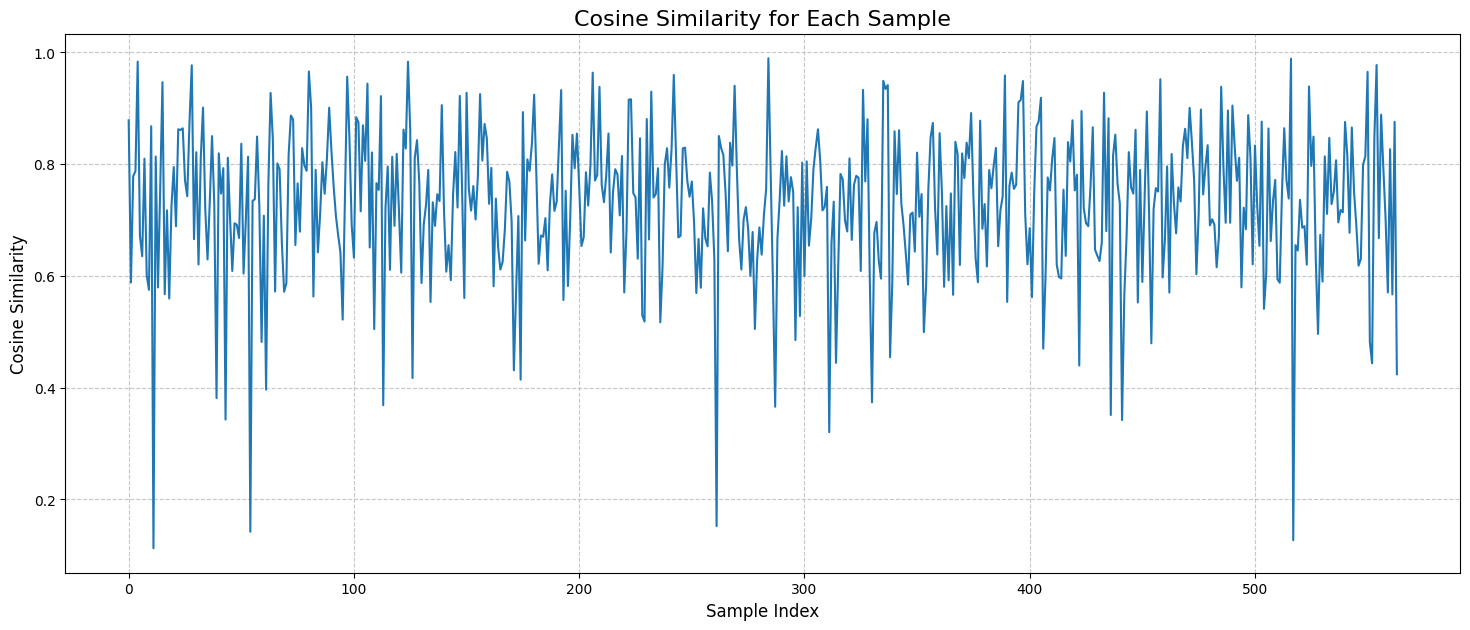

In [ ]:
plt.figure(figsize=(18, 7))
sns.lineplot(x=final_df.index, y=final_df['cosine_sim'])
plt.title('Cosine Similarity for Each Sample', fontsize=16)
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Cosine Similarity', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

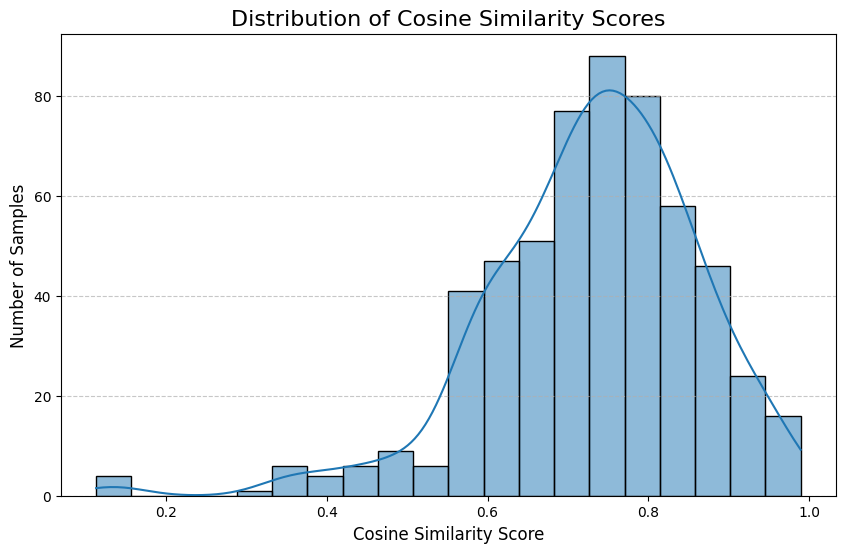

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(final_df['cosine_sim'], bins=20, kde=True)
plt.title('Distribution of Cosine Similarity Scores', fontsize=16)
plt.xlabel('Cosine Similarity Score', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Điếm < 0.4

In [ ]:
low_cosine_sim_samples = final_df[final_df['cosine_sim'] < 0.4]

print(f"Tìm thấy {len(low_cosine_sim_samples)} mẫu có Cosine Similarity < 0.4\n")

if not low_cosine_sim_samples.empty:
    for index, row in low_cosine_sim_samples.iterrows():
        print(f"--- Sample {index} ---")
        print(f"Query: {row['query']}")
        print(f"LLM Answer: {row['llm_answer']}")
        print(f"Human Answer: {row['human_answer']}")
        print(f"Cosine Similarity: {row['cosine_sim']:.4f}")
        print("\n")
else:
    print("Không tìm thấy mẫu nào có Cosine Similarity < 0.4")

Tìm thấy 13 mẫu có Cosine Similarity < 0.4

--- Sample 11 ---
Query: Doanh nghiệp trước khi phá sản có thể quyên góp từ thiện không?
LLM Answer: Không
Human Answer: Theo Điều 59 Luật Phá sản 2014 quy định giao dịch bị coi là vô hiệu, theo đó: 1. Giao dịch của doanh nghiệp, hợp tác xã mất khả năng thanh toán được thực hiện trong thời gian 06 tháng trước ngày Tòa án nhân dân ra quyết định mở thủ tục phá sản bị coi là vô hiệu nếu thuộc một trong các trường hợp sau: a) Giao dịch liên quan đến chuyển nhượng tài sản không theo giá thị trường; b) Chuyển khoản nợ không có bảo đảm thành nợ có bảo đảm hoặc có bảo đảm một phần bằng tài sản của doanh nghiệp, hợp tác xã; c) Thanh toán hoặc bù trừ có lợi cho một chủ nợ đối với khoản nợ chưa đến hạn hoặc với số tiền lớn hơn khoản nợ đến hạn; d) Tặng cho tài sản; đ) Giao dịch ngoài mục đích hoạt động kinh doanh của doanh nghiệp, hợp tác xã; e) Giao dịch khác với mục đích tẩu tán tài sản của doanh nghiệp, hợp tác xã. 2. Giao dịch của doanh nghiệp, hợp 

In [ ]:
specific_sample = low_cosine_sim_samples[low_cosine_sim_samples.index == ]

if not specific_sample.empty:
    for index, row in specific_sample.iterrows():
        print(f"--- Sample {index} ---")
        print(f"Query: {row['query']}")
        print(f"LLM Answer: {row['llm_answer']}")
        print(f"Human Answer: {row['human_answer']}")
        print(f"Cosine Similarity: {row['cosine_sim']:.4f}")
        print(f"BERTScore F1: {row['bertscore_f1']:.4f}")
        print("\n")
else:
    print("Không tìm thấy mẫu 261 có Cosine Similarity < 0.6")

,query,llm_answer,human_answer,cosine_sim,bertscore_f1
517,Trường hợp người gửi có yêu cầu thay đổi địa c...,7000000,Tại khoản 2 Điều 11 Nghị định 15/2020/NĐ-CP có...,0.12716,0.193182


## Điếm <0.6

In [ ]:
low_cosine_sim_samples = final_df[final_df['cosine_sim'] < 0.6]

print(f"Tìm thấy {len(low_cosine_sim_samples)} mẫu có Cosine Similarity < 0.6\n")

if not low_cosine_sim_samples.empty:
    for index, row in low_cosine_sim_samples.iterrows():
        print(f"--- Sample {index} ---")
        print(f"Query: {row['query']}")
        print(f"LLM Answer: {row['llm_answer']}")
        print(f"Human Answer: {row['human_answer']}")
        print(f"Cosine Similarity: {row['cosine_sim']:.4f}")
        print("\n")
else:
    print("Không tìm thấy mẫu nào có Cosine Similarity < 0.6")

Tìm thấy 83 mẫu có Cosine Similarity < 0.6

--- Sample 1 ---
Query: Trong thời gian tập sự hành nghề công chứng người tập sự có được ký văn bản công chứng không?
LLM Answer: Người tập sự hành nghề công chứng không được ký văn bản công chứng.
Human Answer: Điều 11 Luật Công chứng 2014 quy định về tập sự hành nghề công chứng như sau:1. Người có giấy chứng nhận tốt nghiệp khóa đào tạo nghề công chứng hoặc giấy chứng nhận bồi dưỡng nghề công chứng phải tập sự hành nghề tại một tổ chức hành nghề công chứng. Người tập sự có thể tự liên hệ với một tổ chức hành nghề công chứng đủ điều kiện nhận tập sự về việc tập sự tại tổ chức đó; trường hợp không tự liên hệ được thì đề nghị Sở Tư pháp ở địa phương nơi người đó muốn tập sự bố trí tập sự tại một tổ chức hành nghề công chứng đủ điều kiện nhận tập sự.
Người tập sự phải đăng ký tập sự tại Sở Tư pháp ở địa phương nơi có tổ chức hành nghề công chứng nhận tập sự.
Thời gian tập sự hành nghề công chứng là 12 tháng đối với người có giấy chứng nhận tốt 

## BERTscore

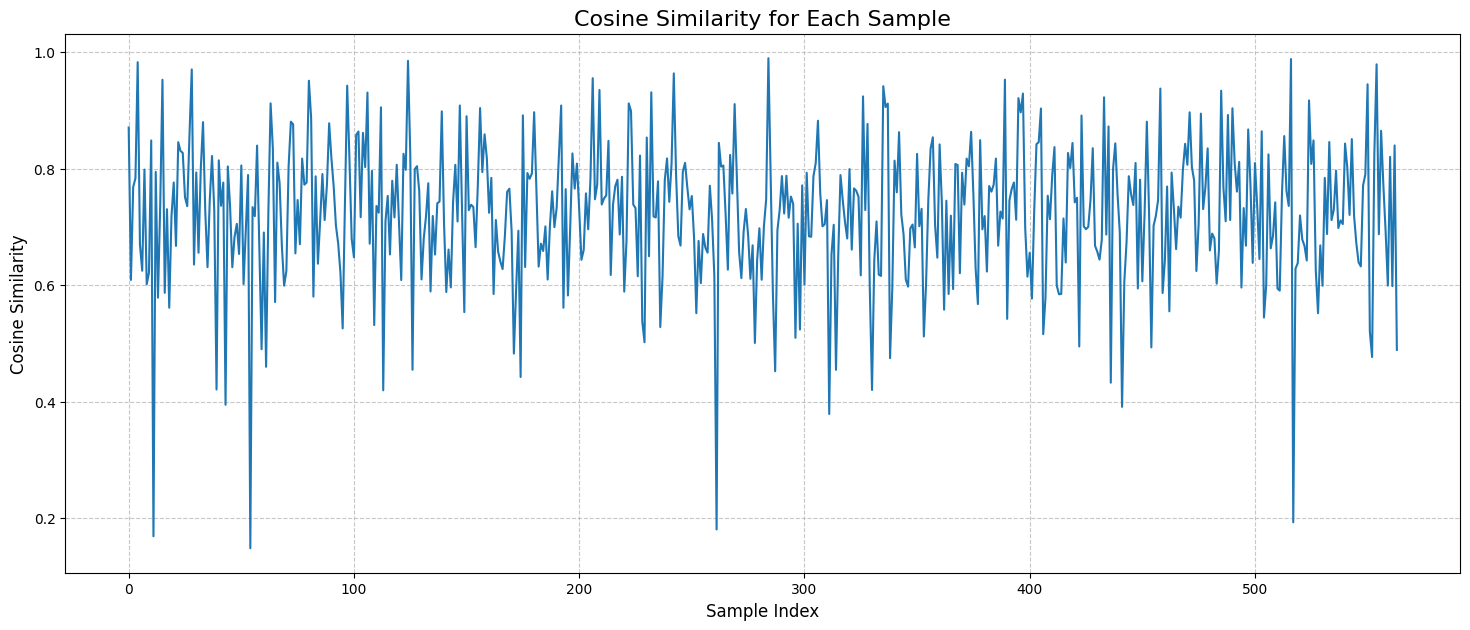

In [ ]:
plt.figure(figsize=(18, 7))
sns.lineplot(x=final_df.index, y=final_df['bertscore_f1'])
plt.title('Cosine Similarity for Each Sample', fontsize=16)
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Cosine Similarity', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

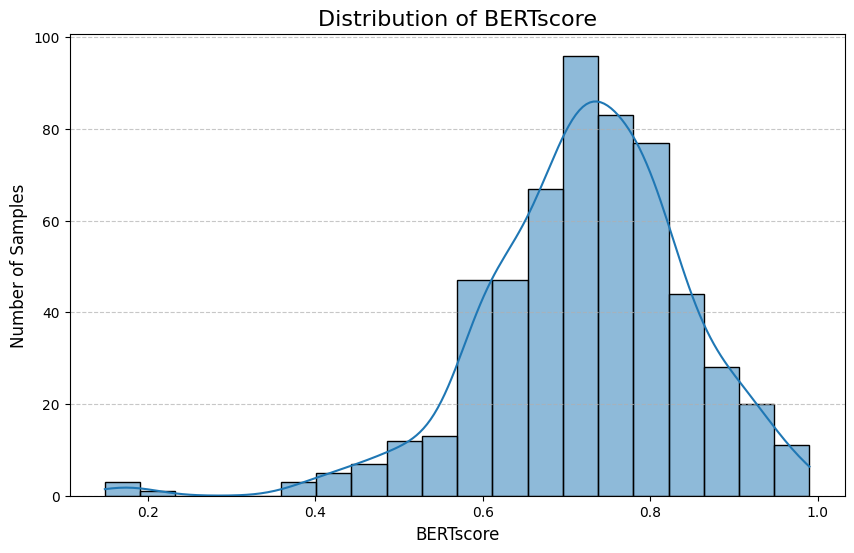

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(final_df['bertscore_f1'], bins=20, kde=True)
plt.title('Distribution of BERTscore', fontsize=16)
plt.xlabel('BERTscore', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

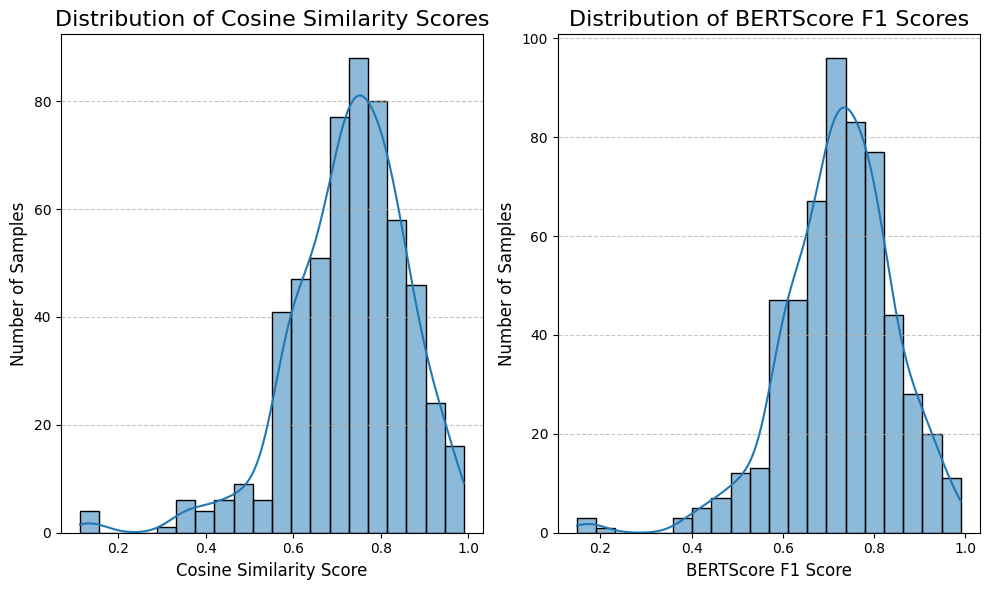

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# Plot for Cosine Similarity
sns.histplot(final_df['cosine_sim'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Cosine Similarity Scores', fontsize=16)
axes[0].set_xlabel('Cosine Similarity Score', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot for BERTScore F1
sns.histplot(final_df['bertscore_f1'], bins=20, kde=True, ax=axes[1])
axes[1].set_title('Distribution of BERTScore F1 Scores', fontsize=16)
axes[1].set_xlabel('BERTScore F1 Score', fontsize=12)
axes[1].set_ylabel('Number of Samples', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()